In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# bank_marketing = fetch_ucirepo(id=222) 
  
# # data (as pandas dataframes) 
# X = bank_marketing.data.features 
# y = bank_marketing.data.targets 
  
# # metadata 
# print(bank_marketing.metadata) 
  
# # variable information 
# print(bank_marketing.variables) 
df = pd.read_csv('bank-full.csv')


## Cleaning Data

In [18]:
df.isna().mean().sort_values(ascending=False)

poutcome       0.817478
contact        0.287983
education      0.041074
job            0.006370
default        0.000000
balance        0.000000
age            0.000000
marital        0.000000
loan           0.000000
housing        0.000000
month          0.000000
day_of_week    0.000000
campaign       0.000000
pdays          0.000000
previous       0.000000
y              0.000000
dtype: float64

In [19]:
#Create new binary variable for never contacted and replace -1 in pdays with 0
df['never_contacted'] = (df['pdays'] == -1).astype(int)
df['pdays'] = df['pdays'].replace(-1, 0)
df['poutcome'] = df['poutcome'].fillna("nonexistent")
#Creating unknown category for missing values in categorical variables
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')

## Plotting Data

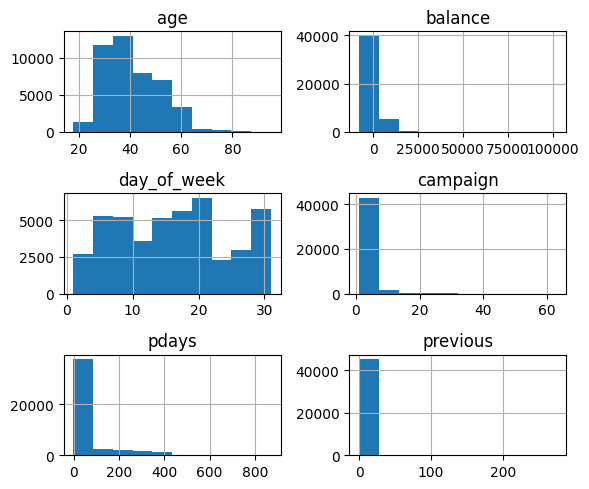

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,1,-1,0,NaN,no


In [17]:
#Duration = Time of last call, but if duration =0, then y = no, so we can drop duration to avoid data leakage.
df.drop(columns=['duration'], inplace=True)
df.hist(figsize=(6,5))
plt.tight_layout()
plt.show()
df.head()

C:\Users\ville\AppData\Local\Temp\ipykernel_28300\2608485904.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


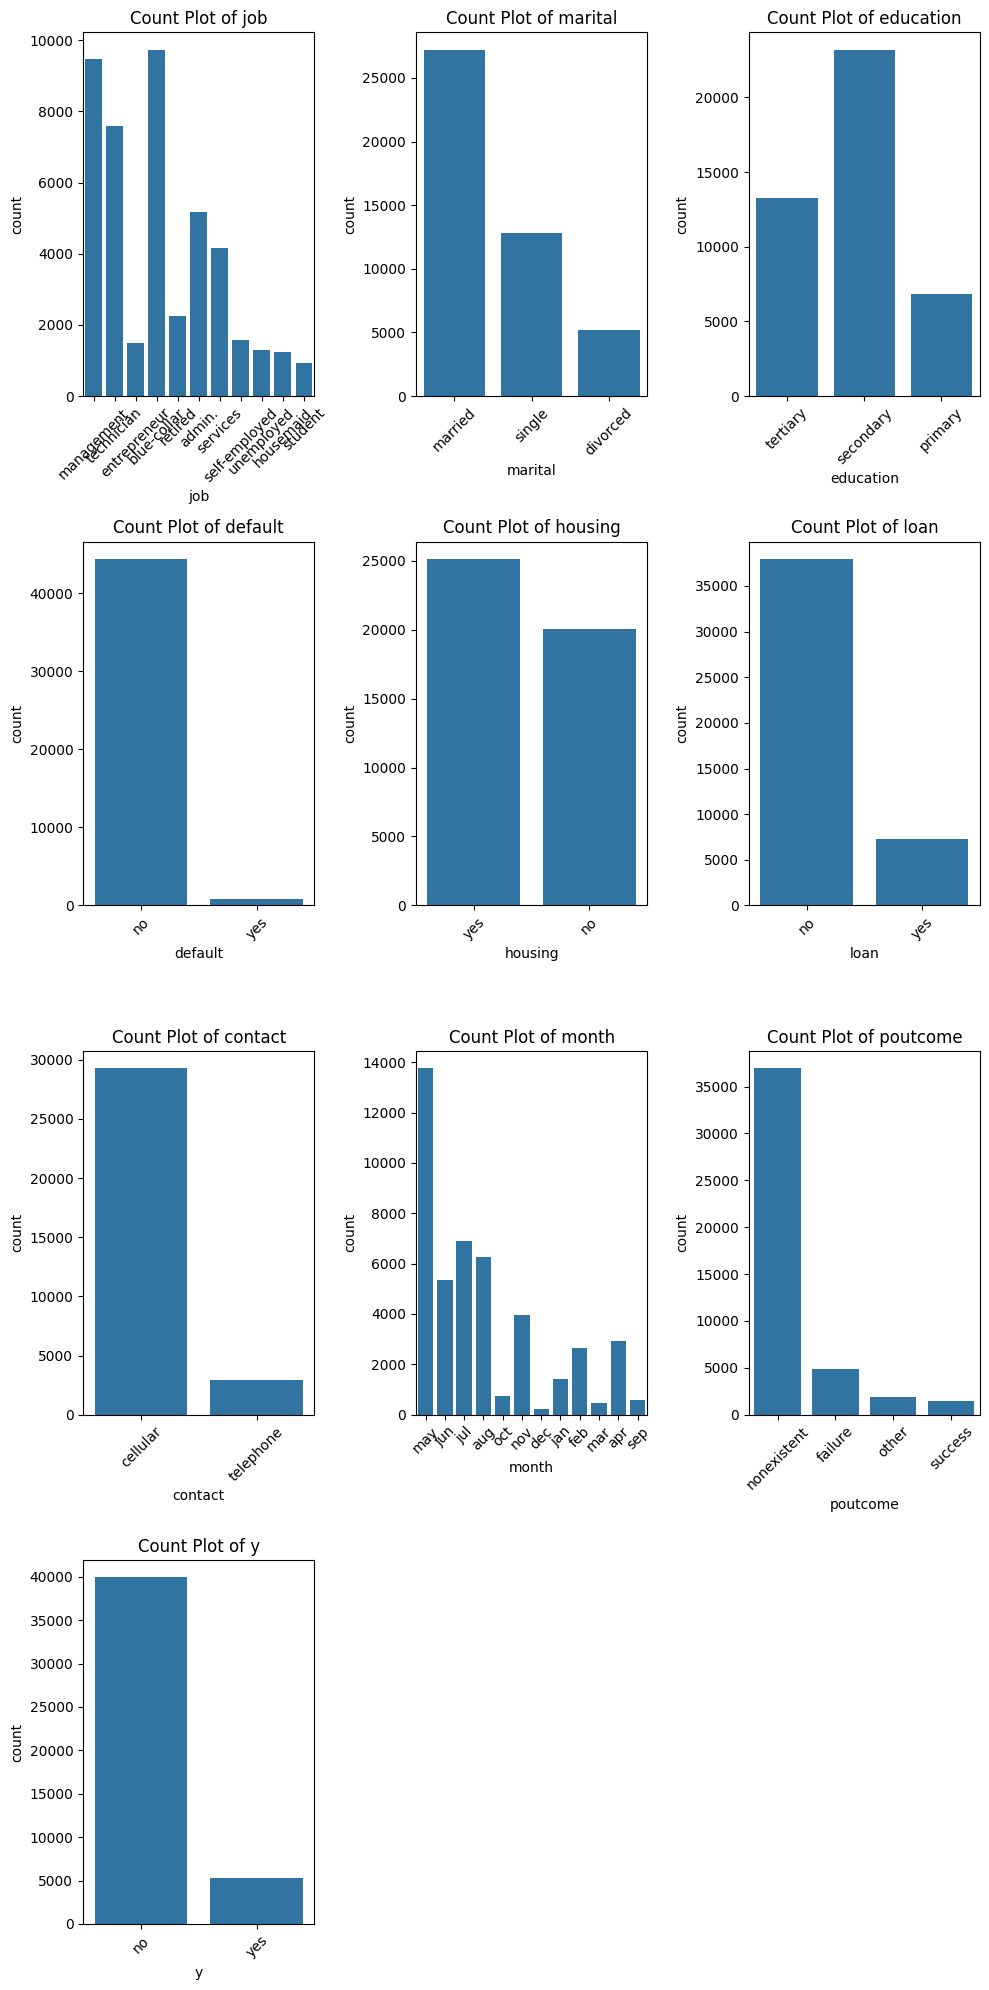

In [20]:

cat_cols = df.select_dtypes(include=['object']).columns

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()